In [1]:
from pathlib import Path
from astropy import units as un
import numpy as np

from edges.cal import sparams as sp
from edges import io
from edges import data as datatools
from edges import alanmode
from edges.cal.thermistor import voltage_to_resistance, get_temperature_thermistor

import matplotlib.pyplot as plt
from edges.io.auxiliary import read_thermlog_file, read_weather_file
from astropy.time import Time
from scipy.interpolate import InterpolatedUnivariateSpline as spline
from tqdm.notebook import tqdm_notebook

## Set Parameters

In [2]:
# NOTEBOOK PARAMETERS (set these to change the behaviour)
outdir: str = '.'

thermistor_model: str = "omega_ON_930_44006"
temperature_file: str = "/data5/edges/data/S11_antenna/low_band/20151207/voltage_20151208_031334.txt"
use_temperature_file: bool = True
constant_receiver_temperature: float = 27.0  # deg celsius, only used if use_temperature_file is False.

legacy_ants11_file: str = "/data5/edges/data/S11_antenna/low_band/S11_blade_low_band_2015_342_03_14.txt"

# Parameters governing the raw antenna S11 measurements
raw_measurements_path: str = "/data5/edges/data/S11_antenna/low_band/20151207/"
raw_measurement_minidx: int = 1000
raw_measurement_maxidx: int = 1750

# Parameters governing the internal switch calibration
match_offset_delay: float = 30.0  # in picoseconds

## Read Data

Read the legacy calibrated S11's, for comparison.

In [3]:
s11freq, s11real, s11imag = np.genfromtxt(legacy_ants11_file).T
mask = (s11freq >=50e6) & (s11freq<=100e6)
s11freq = s11freq[mask]/1e6
orig_s11 = s11real[mask] + 1j*s11imag[mask]

Set the raw s11 data location and the receiver temperature measurement file:

In [4]:
datadir = Path(raw_measurements_path)
temperature_file = Path(temperature_file)

Read the raw antenna S11 files:

In [5]:
def read_raw_ants11_files(datadir, minidx, maxidx):
    input1_files = sorted(datadir.glob("*input1*.s1p"))[minidx:maxidx]
    input2_files = sorted(datadir.glob("*input2*.s1p"))[minidx:maxidx]
    input3_files = sorted(datadir.glob("*input3*.s1p"))[minidx:maxidx]
    input4_files = sorted(datadir.glob("*input4*.s1p"))[minidx:maxidx]
    
    return list(zip(input1_files, input2_files, input3_files, input4_files))

In [6]:
raw_ants11_files = read_raw_ants11_files(datadir, raw_measurement_minidx, raw_measurement_maxidx)

Read the receiver temperatures:

In [7]:
def read_receiver_temepratures(voltage_file):
    voltages = np.genfromtxt(voltage_file)[raw_measurement_minidx:raw_measurement_maxidx, 2] * un.V
    resistance = voltage_to_resistance(voltages, load_resistance=36000*un.Ohm)
    return get_temperature_thermistor(resistance, coeffs=thermistor_model)


In [8]:
if use_temperature_file:
    rcv_temperature = read_receiver_temepratures(temperature_file)
else:
    rcv_temperature = constant_receiver_temperature * un.deg_C

## Obtain the internal switch calibration

In [9]:
def get_switch_state_filespec(d: Path):
    return io.InternalSwitch(
        internal = io.CalkitFileSpec(
            open = d / 'open.S1P',
            short = d/ 'short.S1P',
            match = d/ 'load.S1P',
        ),
        external = io.CalkitFileSpec(
            open = d / 'open_input.S1P',
            short = d/ 'short_input.S1P',
            match = d/ 'load_input.S1P',
        ),
    )

In [10]:
CALKITKW = {"match": {"offset_delay": match_offset_delay*un.picosecond}}

In [11]:
s11root = datatools.fetch_b18cal_s11s()
internal_switch_paths = sorted((s11root / "InternalSwitch").glob("*degC"))
internal_switch_filespecs = [get_switch_state_filespec(d) for d in internal_switch_paths]

In [12]:
intsw_model_params = sp.internal_switch_model_params()

In [13]:
if not use_temperature_file:
    internal_switch = sp.get_internal_switch_from_caldef(internal_switch_filespecs, calkit_overrides=CALKITKW, measured_temperature=rcv_temperature)
    internal_switch_smooth = internal_switch.smoothed(params=intsw_model_params, freqs=ants11.freqs)

## Calibrate the antenna S11s

In [14]:
all_cal_gammas = []
for i, fllist in tqdm_notebook(enumerate(raw_ants11_files), total=len(raw_ants11_files)):
    #fllist = alls11[i*4 : (i+1)*4]
    ck = sp.CalkitReadings.from_filespec(
        io.CalkitFileSpec(
            open=fllist[0],
            short=fllist[1],
            match=fllist[2]
        )
    )
    ants11 = sp.ReflectionCoefficient.from_s1p(fllist[3])    
    
    if use_temperature_file:
        rcvtemp = rcv_temperature[i]
        internal_switch = sp.get_internal_switch_from_caldef(internal_switch_filespecs, calkit_overrides=CALKITKW, measured_temperature=rcvtemp)
        internal_switch_smooth = internal_switch.smoothed(params=intsw_model_params, freqs=ants11.freqs)
    
    
    all_cal_gammas.append(
        sp.calibrate_gamma_src(
            gamma_src=ants11, 
            internal_osl=ck, 
            internal_switch=internal_switch_smooth
        ).select_frequencies(
            f_low=50*un.MHz, 
            f_high=100*un.MHz
        )
    )

  0%|          | 0/750 [00:00<?, ?it/s]

In [15]:
avg_gamma = sp.average_reflection_coefficients(all_cal_gammas)

## Plot a comparison to the legacy data

Text(0.5, 1.0, 'Comparison of recovered antenna S11 to legacy')

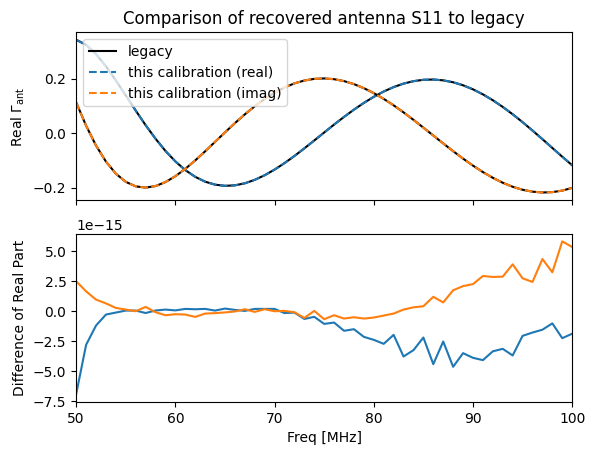

In [16]:
fig, ax = plt.subplots(2, 1, sharex=True)

plt.sca(ax[0])

plt.plot(s11freq, np.real(orig_s11), color='k', ls='-', label='legacy')
plt.plot(avg_gamma.freqs.to_value("MHz"), np.real(avg_gamma.reflection_coefficient), color='C0', label='this calibration (real)', ls='--')

plt.plot(s11freq, np.imag(orig_s11), color='k', ls='-')
plt.plot(avg_gamma.freqs.to_value("MHz"), np.imag(avg_gamma.reflection_coefficient), color='C1', label='this calibration (imag)', ls='--')

plt.xlim(50,100)
plt.legend()
plt.ylabel(r"Real $\Gamma_{\rm ant}$")


plt.sca(ax[1])

# for gg in all_gammas:
#     plt.plot(avg_gamma.freqs.to_value("MHz"), np.real(gg.reflection_coefficient - orig_s11), color='gray', alpha=0.05)
plt.plot(avg_gamma.freqs.to_value("MHz"), np.real(avg_gamma.reflection_coefficient - orig_s11), color='C0')
plt.plot(avg_gamma.freqs.to_value("MHz"), np.imag(avg_gamma.reflection_coefficient - orig_s11), color='C1')

    

#plt.xlim(50,100)
plt.xlabel("Freq [MHz]")
plt.ylabel(r"Difference of Real Part")
#plt.ylim(-1e-6, 1e-6)
ax[0].set_title("Comparison of recovered antenna S11 to legacy")

In [17]:
avg_gamma.write(f"{outdir}/2015_ants11_modelled.h5")